# Trigger wave thresholds

In [1]:
import immunowave as iw
import numpy as np
import jax
import jax.numpy as jnp
import diffrax as dx

import matplotlib as mpl
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

## Model definition

Define the state and model for model 4 from the text.

In [2]:
class State4(iw.State):
    A: iw.ScalarField
    B: iw.ScalarField

In [3]:
class Model4(iw.Model):
    θ: float
    η: float
    ξ: float
    λ: float
    μ: float

    def __call__(self, t, state, args=None):
        # unpack field variables
        A, B = state.A, state.B
        # unpack parameters
        θ, η, ξ, λ, μ = self.θ, self.η, self.ξ, self.λ, self.μ
        # define PDE
        dAdt = A.laplacian(bc="neumann") + A * (A - θ) * (1 - A) + η * B
        dBdt = ξ * B.laplacian(bc="neumann") + λ * B * (1 - B) - μ * A * B
        return State4(dAdt, dBdt)

Instantiate model

In [4]:
model = Model4(θ=0.1, η=1.0, ξ=0.0, λ=0.0, μ=1.0)
model

Model4(θ=0.1, η=1.0, ξ=0.0, λ=0.0, μ=1.0)

## Immune response outcomes

Define immune response outcome in terms of the value of the $A$ field.
- If mean response $\frac{1}{L}\int_0^{L}A\left(x, t\right)\mathrm{d}x > 0.9$, then a tissue-scale response has been triggered at time $t$.
- If the mean response is small $\frac{1}{L}\int_0^{L}A\left(x, t\right)\mathrm{d}x < \frac{\theta}{2}$ while it is shrinking $\frac{\mathrm{d}}{\mathrm{d}t}\int_0^{L}A\left(x, t\right)\mathrm{d}x < 0$, then a transient response has subsided.

In [5]:
outcomes = ["inconclusive", "triggered", "transient"]


@jax.jit
def outcome(state, t, model):
    A_integral = state.A.integral()
    triggered = A_integral / L > 0.9
    low_activation = A_integral / L < model.θ / 10
    shrinking_activation = model(t, state).A.integral() < 0

    return jnp.where(
        triggered,
        1,
        jnp.where(
            jax.lax.bitwise_and(low_activation, shrinking_activation),
            2,
            0,
        ),
    )

## Solve

We set the upper bound of the integration region to infinity, and then terminate integration only when we encounter one of the two immune response events: tissue-scale triggering, or a transient response.

In [6]:
t0 = 0.0
t1 = jnp.inf

kwargs = dict(dt0=1e-4, max_steps=1000000, atol=1e-8, rtol=1e-8)

Instantiate state

In [7]:
L = 20.0
n = 1000

shape = (n,)
lb = [0]
h = L / (n - 1)

In [8]:
state = State4(
    A=iw.ScalarField(shape, lb, h, 0),
    B=iw.ScalarField(
        shape, lb, h, fn=lambda x: 0.5 * jnp.exp(-((x - L / 2) ** 2) / (2 * 0.1**2))
    ),
)

Solve

In [9]:
solution = iw.solve(
    model,
    state,
    t0,
    t1,
    **kwargs,
    discrete_terminating_event=dx.DiscreteTerminatingEvent(
        lambda solver_state, **kwargs: outcome(
            solver_state.y, solver_state.tprev, model
        )
    ),
)

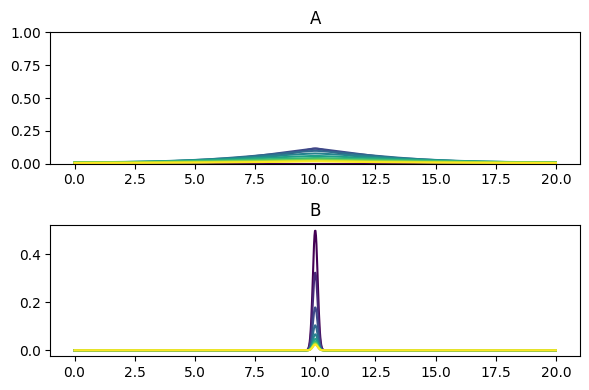

In [10]:
ts = solution.interpolation.ts[solution.interpolation.ts < np.inf]

cmap = plt.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=ts[0], vmax=ts[-1]), cmap=plt.cm.viridis
)

axes = None
for ti in np.linspace(ts[0], ts[-1], 10):
    axes = solution.evaluate(ti).plot(axes=axes, color=cmap.to_rgba(ti))
axes[0].set_ylim(0, max(1, solution.evaluate(ti).A.values.max()))
plt.show()

Integration was terminated at this time

In [11]:
ts[-1]

Array(45.2513, dtype=float64, weak_type=True)

The termination event was

In [12]:
outcomes[outcome(solution.evaluate(ts[-1]), ts[-1], model)]

'transient'

## Solve with a stronger bacterial stimulus

In [13]:
state = State4(
    A=iw.ScalarField(shape, lb, h, 0),
    B=iw.ScalarField(
        shape, lb, h, fn=lambda x: 10 * jnp.exp(-((x - L / 2) ** 2) / (2 * 0.1**2))
    ),
)

In [14]:
solution = iw.solve(
    model,
    state,
    t0,
    t1,
    **kwargs,
    discrete_terminating_event=dx.DiscreteTerminatingEvent(
        lambda solver_state, **kwargs: outcome(
            solver_state.y, solver_state.tprev, model
        )
    ),
)

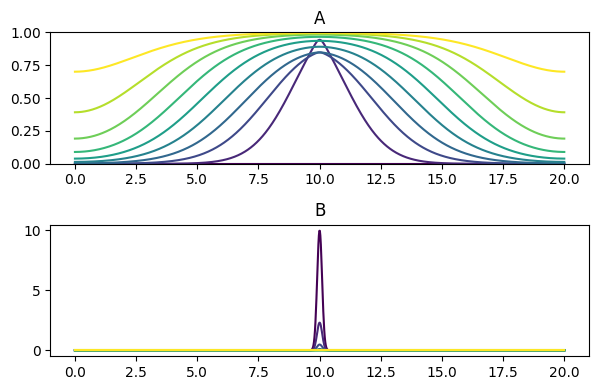

In [15]:
ts = solution.interpolation.ts[solution.interpolation.ts < np.inf]

cmap = plt.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=ts[0], vmax=ts[-1]), cmap=plt.cm.viridis
)

axes = None
for ti in np.linspace(ts[0], ts[-1], 10):
    axes = solution.evaluate(ti).plot(axes=axes, color=cmap.to_rgba(ti))
axes[0].set_ylim(0, max(1, solution.evaluate(ti).A.values.max()))
plt.show()

In [16]:
ts[-1]

Array(15.9221, dtype=float64, weak_type=True)

In [17]:
outcomes[outcome(solution.evaluate(ts[-1]), ts[-1], model)]

'triggered'